# NiI₂ (A-type AFM) simulated ARPES via **VASP**

**NiI₂** is the layered transition-metal dihalide that became a flagship **type-II multiferroic**, in bulk (Kurumaji *et al.*, *Phys. Rev. B* **87**, 014429 (2013)) and down to the monolayer (Song *et al.*, *Nature* **602**, 601 (2022)). Its true ground state is an incommensurate proper-screw helimagnet; here we model the **collinear A-type antiferromagnet** — ferromagnetic Ni triangular planes stacked antiferromagnetically along $c$ (intralayer AFM is impossible collinearly on the frustrated triangular lattice; the in-plane exchange $J_1$ is ferromagnetic).

**The magnetic cell.** On the experimental **ABC-stacked ($R\bar3m$)** lattice the Ni layers repeat with period 3, while A-type spin order repeats with period 2, so the fully commensurate magnetic+structural cell is their least common multiple — **6 Ni layers** (↑↓↑↓↑↓, 6 f.u., Ni₆I₁₂). This keeps the true hexagonal in-plane axes *and* the real ABC stacking, and gives a clean $(0,0,1)$ van-der-Waals cleave — more physical than a folded 2-layer sublattice cell.

The DFT + Wannier overlaps run in **VASP** (`vasp_ncl`, noncollinear + SOC) through `waw.interfaces.vasp`: **PBE + Grimme-D3 + $U$** with **$U=4$, $J=0$ eV** on Ni-$3d$ (a plain Hubbard $U$; the pressure-optimised $U=3.24$/$J=0.68$ are not appropriate here), MatPES PAW POTCARs (Ni_pv 16 e⁻, I 7 e⁻), and **132 Ni-$3d$/I-$5p$ spinor MLWFs**. waw then does the disentangle + MLWF and all the surface/ARPES analysis. Unlike the paramagnetic case, A-type $+U$ **opens the insulating Mott/charge-transfer gap**.

In [1]:
import os, sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
from waw.interfaces import quantum_espresso as qe   # the direct-input QE driver
from waw.interfaces.ase.driver import wannierize
from waw.units import BOHR_TO_ANG, HARTREE_TO_EV, EV_TO_HARTREE
from waw.vis import plot_bands, BandSeries

PSEUDO_DIR = REPO / 'workflows' / 'pseudos'   # shared across workflows/, not notebooks/-specific
NCORES = 16
waw.set_num_threads(NCORES)
print('waw', 'threads =', waw.get_num_threads(), '| repo', REPO)

waw threads = 16 | repo /aims_data/miguel/nas-data001/claude/wannier


### 1. The A-type AFM 6-layer hexagonal cell
Build the $R\bar3m$ hexagonal conventional cell (3 Ni layers, ABC), double it along $c$ (→ 6 Ni layers), and tag the Ni into up/down sublattices by the parity of their layer index along $c$ — giving the ↑↓↑↓↑↓ A-type stack. The two in-plane vectors stay in the $z=0$ plane, so the ⟂$c$ cleave is Miller $(0,0,1)$.

In [2]:
from ase.spacegroup import crystal
from ase.build import make_supercell
from waw.interfaces import vasp
from waw.interfaces.ase.structure import real_lattice, recip_lattice, band_path
from waw.interfaces.projections import spd_projections
from waw.analysis.surface import surface_spectral_function
from waw.core.hamiltonian import interpolate_bands

A_HEX, C_HEX = 3.892, 19.634    # COD 9009133, R-3m (166)
hexc = crystal(['Ni', 'I'], basis=[(0, 0, 0), (0, 0, 0.25)],
               spacegroup=166, cellpar=[A_HEX, A_HEX, C_HEX, 90, 90, 120],
               primitive_cell=False)          # hexagonal conventional: 3 Ni layers (ABC)
atoms = make_supercell(hexc, np.diag([1, 1, 2]))   # double along c -> 6 Ni layers, Ni6 I12

# tag Ni into up(1)/down(2) sublattices by layer parity along c (A-type)
c_hat = np.array([0.0, 0.0, 1.0])
interlayer = C_HEX / 3.0                  # 3 Ni layers per hexagonal c
tags = np.zeros(len(atoms), dtype=int)
for i, (s, pos) in enumerate(zip(atoms.get_chemical_symbols(), atoms.positions)):
    if s == 'Ni':
        layer = int(round((pos @ c_hat) / interlayer))
        tags[i] = 1 if layer % 2 == 0 else 2
atoms.set_tags(tags)

n_up = int(np.sum((tags == 1)))
n_dn = int(np.sum((tags == 2)))
assert n_up == n_dn == 3, f'expected 3 up + 3 down Ni, got {n_up}/{n_dn}'
in_plane = np.array(atoms.cell)[:2]
assert np.allclose(in_plane[:, 2], 0, atol=1e-6)   # v1,v2 in the z=0 plane
MILLER = (0, 0, 1)

ni_h = sorted(float(p @ c_hat) for s, p in
              zip(atoms.get_chemical_symbols(), atoms.positions) if s == 'Ni')
print('magnetic cell:', atoms.get_chemical_formula(), '| natoms', len(atoms))
print('Ni layer heights along c (Ang):', np.round(ni_h, 3))

magnetic cell: I12Ni6 | natoms 18
Ni layer heights along c (Ang): [ 0.     6.545 13.089 19.634 26.179 32.723]


### 2. Noncollinear + SOC PBE+D3+U (VASP) and Wannierisation
`vasp.generate_overlaps` runs one VASP SCF with the VASP2WANNIER90 interface (`LWANNIER90`, `vasp_ncl`) and returns the `wannier90.mmn/.amn/.eig` overlaps in the same dict shape as `qe.generate_overlaps`. **A-type AFM** via per-atom noncollinear `MAGMOM` (up-layer Ni $+z$, down-layer Ni $-z$; I = 0). **$U=4$, $J=0$** on Ni-$3d$ (`LDAUTYPE=1`, `LDAUU=4`, `LDAUJ=0`), Grimme-D3. **132 spinor MLWFs** — Ni-$3d$ (×6 Ni) + I-$5p$ (×12 I), ×2 for spin. With $+U$ the Ni-$3d$/I-$5p$ manifold is an **isolated, insulating** set (clean gap to the I-$5s$ semicore below and to higher conduction above), so the disentanglement window brackets it and freezes it whole.

In [3]:
MP_GRID = (6, 6, 4)   # 4 points along the 39 Ang c axis: with only 2, both Gamma and A
                      # fall on the mesh and H(R_3) keeps a single harmonic, leaving the
                      # dispersion between them unconstrained
WORK = HERE / 'runs' / 'nii2_vasp_kz4'

frac = atoms.get_scaled_positions()
syms = atoms.get_chemical_symbols()
ni_sites = [tuple(p) for s, p in zip(syms, frac) if s == 'Ni']
i_sites  = [tuple(p) for s, p in zip(syms, frac) if s == 'I']
# keep the spd_projections specs (used by wannier_lm_from_projections in the
# ARPES section); VASP gets the equivalent wannier90.win projector strings.
projections = [p for s in ni_sites for p in spd_projections(s, 'd')] + \
              [p for s in i_sites for p in spd_projections(s, 'p')]
NUM_WANN = len(projections) * 2          # x2 spinor -> 132
win_proj = [f'f={p[0]:.6f},{p[1]:.6f},{p[2]:.6f}:d' for p in ni_sites] + \
           [f'f={p[0]:.6f},{p[1]:.6f},{p[2]:.6f}:p' for p in i_sites]

# A-type AFM (Ni tag1 -> +z, tag2 -> -z; I -> 0); U=4, J=0 on Ni-3d; Grimme-D3.
LDAU = {'Ni': {'L': 2, 'U': 4.0, 'J': 0.0}}
ov = vasp.generate_overlaps(
    atoms, MP_GRID, WORK, projections=win_proj, num_wann=NUM_WANN,
    encut=520, nbands=220, moments={1: 2.0, 2: -2.0}, ldau=LDAU, ivdw=11,
    noncollinear=True, lsorbit=True, ncores=NCORES,
    rerun=False,   # reuse a finished run in runs/nii2_vasp/
)
E_FERMI = ov['fermi_energy']
print(f'E_F = {E_FERMI:.4f} eV, num_wann = {NUM_WANN}, bands = {ov["eig"].shape[1]}')

E_F = 5.1809 eV, num_wann = 132, bands = 224


In [4]:
# validate the A-type order from VASP: OSZICAR's final line carries the total
# noncollinear moment (~0 for A-type; FM planes cancel between up/down layers).
osz = (WORK / 'OSZICAR').read_text().splitlines()
print('OSZICAR (last):', osz[-1].strip())
print('-> total moment ~ 0 = A-type AFM (FM Ni planes, antiferromagnetically stacked)')

OSZICAR (last): 1 F= -.46638343E+02 E0= -.46638343E+02  d E =-.190641E-11  mag=    -0.0004     0.0000    -0.0000
-> total moment ~ 0 = A-type AFM (FM Ni planes, antiferromagnetically stacked)


In [5]:
# With +U the Ni-3d/I-5p manifold is an ISOLATED, INSULATING set of 132 bands:
# a gap separates it from the I-5s semicore below and from higher conduction
# above. Bound the disentanglement window to the manifold and FREEZE it whole.
OUTER = (E_FERMI - 8.0, E_FERMI + 1.5)   # brackets bands 60-191 (132): 6.5 eV gap to I-5s below, 0.68 eV gap to conduction above

# Cache the Wannierization (the MLWF minimization is the expensive step).
WANN_CACHE = WORK / 'nii2_wannier.npz'
if WANN_CACHE.exists():
    result = waw.load_wannier_result(WANN_CACHE)
    print('loaded cached Wannierization:', WANN_CACHE.name)
else:
    result = wannierize(
        atoms, MP_GRID, ov['kpts'],
        mmn=ov['mmn'], amn=ov['amn'], eig=ov['eig'],
        nnkpts=ov['nnkpts'], g_vectors=ov['g_vectors'], nw=NUM_WANN,
        outer_window=OUTER, frozen_window=OUTER,
        guiding_centres=True, optimizer='cg',
        n_restarts=1, dis_n_iter=200, n_iter=3000, conv_tol=1e-8, conv_window=40, verbose=False,
    )
    waw.save_wannier_result(result, WANN_CACHE)
real_lattice_ = real_lattice(atoms)
print(f'Omega_I = {result.dis.omega_i * BOHR_TO_ANG**2:.4f} Ang^2, '
      f'Omega_total = {result.omega_final * BOHR_TO_ANG**2:.4f} Ang^2')

loaded cached Wannierization: nii2_wannier.npz
Omega_I = 197.6204 Ang^2, Omega_total = 202.3325 Ang^2


### 3. Validate the Wannier functions: DFT vs. interpolated bands
A non-self-consistent VASP bands run (`vasp.bands`, `ICHARG=11`, reusing the SCF `CHGCAR`) along the hexagonal-BZ path $\Gamma$–M–K–$\Gamma$–A–L–H–A (Kapeghian *et al.*, *Phys. Rev. B* **109**, 014403 (2024), Fig. 8), overlaid with `interpolate_bands`. Agreement across the frozen window confirms the 132-orbital model.

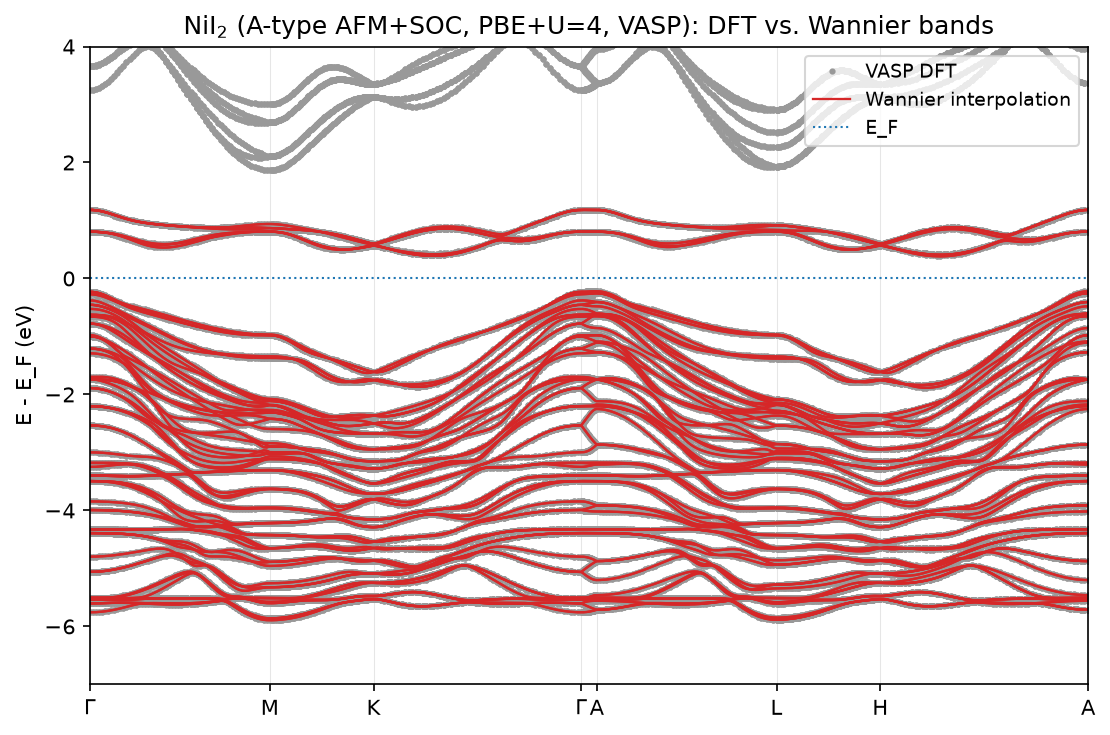

DFT band offset of the 132-WF manifold: 60
segment   max|wann-DFT|   rms      DFT dispersion   % of x-axis
  G-M         13.2 meV     2.6        750.4 meV       18.02%
  M-K         11.0 meV     2.1        293.2 meV       10.40%
  K-G         14.3 meV     3.0        956.0 meV       20.81%
  G-A          1.3 meV     0.5         44.0 meV        1.55%
  A-L         13.7 meV     2.6        750.5 meV       18.02%
  L-H         10.6 meV     2.1        291.9 meV       10.40%
  H-A         14.5 meV     3.1        958.3 meV       20.81%


In [6]:
from waw.analysis.kpath import build_kpath

HEX = {'G': (0, 0, 0), 'M': (0.5, 0, 0), 'K': (1/3, 1/3, 0),
       'A': (0, 0, 0.5), 'L': (0.5, 0, 0.5), 'H': (1/3, 1/3, 0.5)}
seq = ['G', 'M', 'K', 'G', 'A', 'L', 'H', 'A']
segs = [(seq[i], np.array(HEX[seq[i]]), seq[i+1], np.array(HEX[seq[i+1]]))
        for i in range(len(seq) - 1)]
kp = build_kpath(segs, recip_lattice(atoms), n_points=60)

dft_bands = vasp.bands(atoms, WORK, kp.kpts, encut=520, nbands=220,
                       moments={1: 2.0, 2: -2.0}, ldau=LDAU, ivdw=11,
                       noncollinear=True, lsorbit=True, ncores=NCORES, rerun=False)
wann_bands = interpolate_bands(result.hr, kp.kpts) * HARTREE_TO_EV

xlabels = [l.replace('G', r'$\Gamma$') for l in kp.tick_labels]
fig, ax = plt.subplots(figsize=(7.5, 5), dpi=150)
for ib in range(dft_bands.shape[1]):
    ax.plot(kp.dists, dft_bands[:, ib] - E_FERMI, 'o', ms=2.0, color='0.6',
            label='VASP DFT' if ib == 0 else None)
for ib in range(wann_bands.shape[1]):
    ax.plot(kp.dists, wann_bands[:, ib] - E_FERMI, '-', lw=1.1, color='C3',
            label='Wannier interpolation' if ib == 0 else None)
ax.axhline(0.0, color='C0', ls=':', lw=1, label='E_F')
ax.set_xticks(kp.tick_dists); ax.set_xticklabels(xlabels)
for x in kp.tick_dists:
    ax.axvline(x, color='0.9', lw=0.5, zorder=0)
ax.set_xlim(kp.dists[0], kp.dists[-1]); ax.set_ylim(-7, 4)
ax.set_ylabel('E - E_F (eV)')
ax.set_title('NiI$_2$ (A-type AFM+SOC, PBE+U=4, VASP): DFT vs. Wannier bands')
ax.legend(fontsize=9, loc='upper right'); plt.tight_layout(); plt.show()

# Per-segment deviation from the ab-initio bands. The manifold is DFT bands
# [off, off+132); the offset follows from matching at Gamma.
_d, _w = dft_bands - E_FERMI, wann_bands - E_FERMI
_off = min(range(0, _d.shape[1] - NUM_WANN),
           key=lambda o: np.abs(_w[0] - _d[0, o:o + NUM_WANN]).max())
print(f'DFT band offset of the {NUM_WANN}-WF manifold: {_off}')
print('segment   max|wann-DFT|   rms      DFT dispersion   % of x-axis')
for _i in range(len(seq) - 1):
    _a = int(np.searchsorted(kp.dists, kp.tick_dists[_i], 'left'))
    _b = int(np.searchsorted(kp.dists, kp.tick_dists[_i + 1], 'right'))
    _dd = np.abs(_w[_a:_b] - _d[_a:_b, _off:_off + NUM_WANN])
    _disp = (_d[_a:_b, _off:_off + NUM_WANN].max(0) - _d[_a:_b, _off:_off + NUM_WANN].min(0)).mean()
    _frac = (kp.tick_dists[_i + 1] - kp.tick_dists[_i]) / (kp.tick_dists[-1] - kp.tick_dists[0])
    print(f'  {seq[_i]}-{seq[_i+1]}     {1e3*_dd.max():8.1f} meV  {1e3*np.sqrt((_dd**2).mean()):6.1f}'
          f'      {1e3*_disp:7.1f} meV       {100*_frac:5.2f}%')


### 4. Surface spectral function on the (001) van-der-Waals cleave
$A(\mathbf k_\parallel, E)=-\tfrac1\pi\,\mathrm{Im\,Tr}\,G_s$ of the semi-infinite crystal cleaved ⟂ $c$ (Lopez-Sancho/Rubio decimation, `analysis.surface`), along $\bar\Gamma\!\to\!\bar M\!\to\!\bar K\!\to\!\bar\Gamma$ of the hexagonal surface BZ. This is the simulated ARPES dispersion; its constant-energy cuts are the Fermi-surface maps of Section 5.

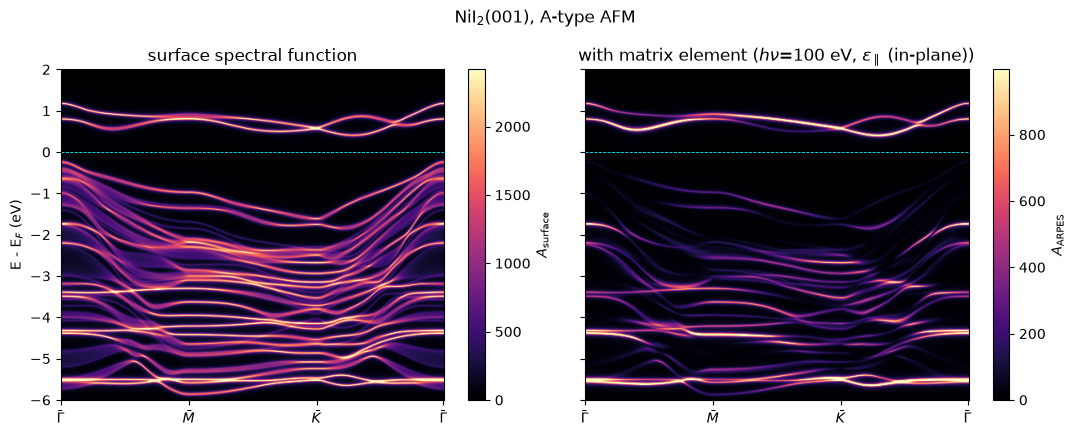

In [7]:
from waw.analysis.arpes import photoemission_matrix_element, wannier_lm_from_projections

NK = 120
def _seg(a, b, n, end=False): return np.linspace(a, b, n, endpoint=end)
G, M, K = np.array([0., 0.]), np.array([0.5, 0.]), np.array([1/3, 1/3])
kpath = np.concatenate([_seg(G, M, NK), _seg(M, K, NK), _seg(K, G, NK, end=True)])
seg_bounds = [0, NK, 2 * NK, 3 * NK - 1]

energies_eV = E_FERMI + np.linspace(-6.0, 2.0, 400)

# the bare surface spectral function, and the same thing weighted by the
# photoemission matrix element -- what a detector would actually record. Having
# them side by side is what makes the constant-energy maps below readable: a
# contour that is bright in A_surface but dark in A_ARPES is suppressed by the
# matrix element, not absent from the band structure.
a2d = real_lattice_[:2, :2]
g2d = 2 * np.pi * np.linalg.inv(a2d).T
wf_lm = wannier_lm_from_projections(projections, spinor=True)
HV = 100.0
POLS = [(r'$\varepsilon_\parallel$ (in-plane)', [1, 0, 0]),
        (r'$\varepsilon_\perp$ (out-of-plane)', [0, 0, 1])]

sf = surface_spectral_function(result.hr, real_lattice_, MILLER, kpath,
                               energies_eV * EV_TO_HARTREE, eta=0.02 * EV_TO_HARTREE)
M_path = photoemission_matrix_element(kpath @ g2d, result.centres_bohr, wf_lm,
                                      POLS[0][1], HV)
sf_me = surface_spectral_function(result.hr, real_lattice_, MILLER, kpath,
                                  energies_eV * EV_TO_HARTREE,
                                  eta=0.02 * EV_TO_HARTREE, matrix_element=M_path,
                                  backend='batched')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
ext = [0, len(kpath), energies_eV[0] - E_FERMI, energies_eV[-1] - E_FERMI]
for ax, A, lab in ((axes[0], sf.A_surface, r'$A_\mathrm{surface}$'),
                   (axes[1], sf_me.A_arpes, r'$A_\mathrm{ARPES}$')):
    im = ax.imshow(A.T, origin='lower', aspect='auto', cmap='magma', extent=ext,
                   vmin=0, vmax=np.percentile(A, 99))
    ax.axhline(0.0, color='cyan', lw=0.6, ls='--')
    ax.set_xticks(seg_bounds)
    ax.set_xticklabels([r'$\bar\Gamma$', r'$\bar M$', r'$\bar K$', r'$\bar\Gamma$'])
    fig.colorbar(im, ax=ax, label=lab)
axes[0].set_ylabel('E - E$_F$ (eV)')
axes[0].set_title('surface spectral function')
axes[1].set_title(rf'with matrix element ($h\nu$={HV:.0f} eV, {POLS[0][0]})')
fig.suptitle('NiI$_2$(001), A-type AFM')
plt.tight_layout(); plt.show()

### 5. Constant-energy ARPES maps vs. light polarisation
The constant-energy cuts $A_\mathrm{ARPES}(k_x,k_y;\,E)$ of the (001) surface spectral function over the 2D surface BZ — the **Fermi-surface maps** — weighted by the **photoemission matrix element** $I\propto M^\dagger A\,M$ (`analysis.arpes`, plane-wave final state), for the two light polarisations an experimentalist toggles: **$\varepsilon_\parallel$** (in-plane, $\varepsilon\parallel a$) and **$\varepsilon_\perp$** (out-of-plane, $\varepsilon\parallel c$). Rows step the energy by **0.25 eV** across the whole Ni-$3d$/I-$5p$ manifold — from the **top of the conduction bands** down to the **bottom of the valence manifold** (auto-detected from the Wannier bands); the insulating $+U$ gap shows up as dark (empty) cuts. The matrix element encodes the structure-factor phase, the $\ell\!\to\!\ell\pm1$ dipole rules, and the polarisation.

30 constant-energy maps from E_F+1.25 to E_F-6.00 eV


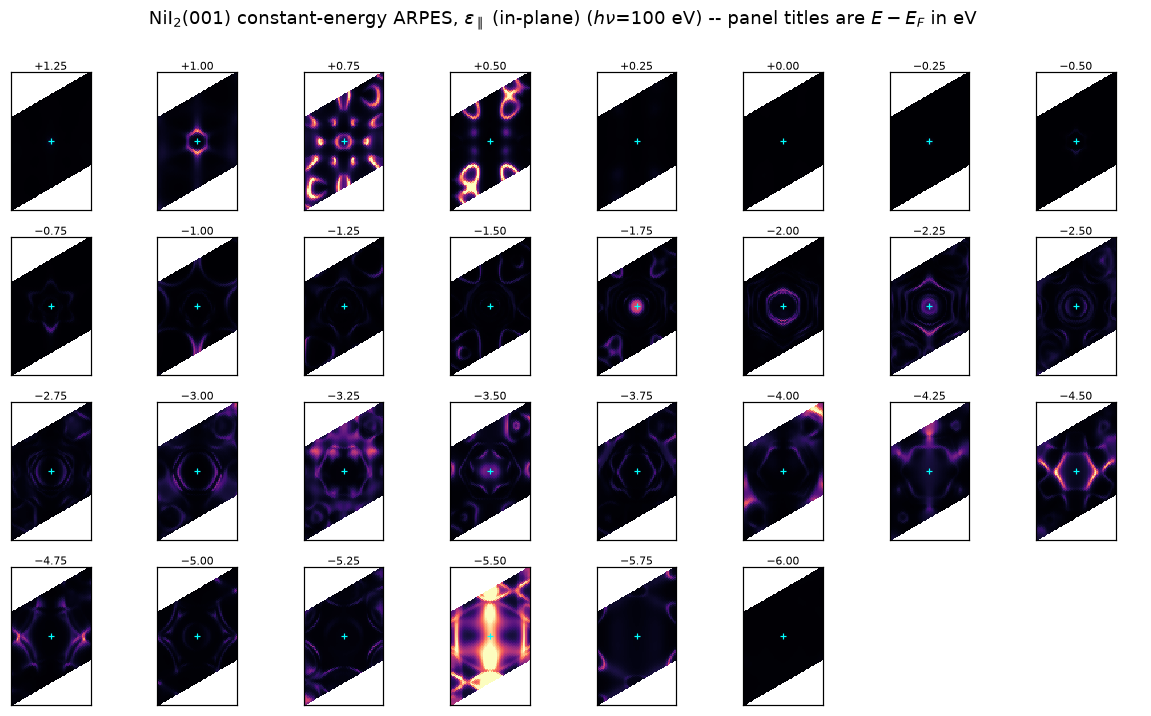

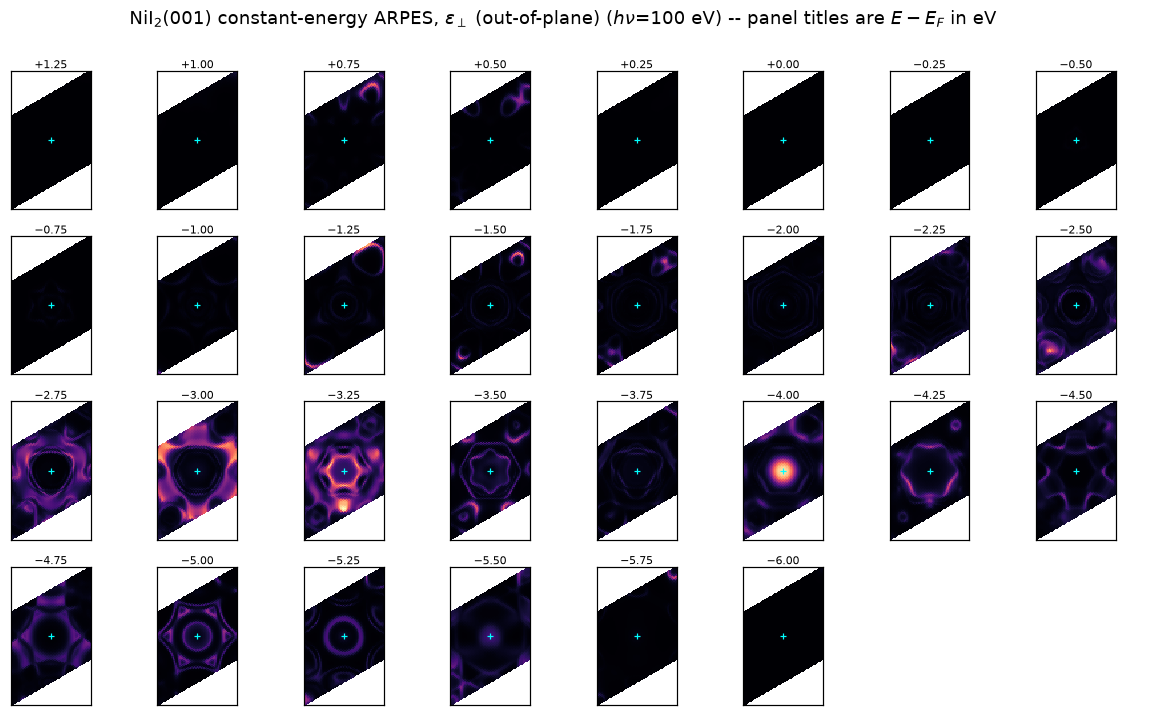

In [8]:
# energy window: top of the manifold down to its bottom, in 0.25 eV steps
wb_grid = interpolate_bands(result.hr, atoms.cell.bandpath(npoints=600).kpts) * HARTREE_TO_EV
E_TOP = np.ceil((wb_grid.max() - E_FERMI) / 0.25) * 0.25
E_BOT = np.floor((wb_grid.min() - E_FERMI) / 0.25) * 0.25
dEs = np.arange(E_TOP, E_BOT - 1e-9, -0.25)   # high -> low energy
print(f'{len(dEs)} constant-energy maps from E_F{E_TOP:+.2f} to E_F{E_BOT:+.2f} eV')

# 2D surface BZ grid (kx,ky), hexagonal, Gamma-bar centred
a2d = real_lattice_[:2, :2]
g2d = 2 * np.pi * np.linalg.inv(a2d).T
N = 61
f = np.linspace(-0.5, 0.5, N)
F1, F2 = np.meshgrid(f, f, indexing='ij')
frac2d = np.stack([F1.ravel(), F2.ravel()], axis=1)
kcart = frac2d @ g2d
KX = kcart[:, 0].reshape(N, N); KY = kcart[:, 1].reshape(N, N)

wf_ctr = result.centres_bohr        # wf_lm, HV, POLS set above

energies2d = E_FERMI + dEs
fs = []
for _, eps in POLS:
    M = photoemission_matrix_element(kcart, wf_ctr, wf_lm, eps, HV)
    a = surface_spectral_function(result.hr, real_lattice_, MILLER, frac2d,
                                  energies2d * EV_TO_HARTREE, eta=0.03 * EV_TO_HARTREE,
                                  matrix_element=M, backend='batched')
    fs.append(a.A_arpes)                        # (nk, nE)
vmax = max(np.percentile(a, 99.5) for a in fs)

# One compact grid per polarisation: a column per energy is unreadable once the
# manifold needs ~30 maps (the figure ends up metres tall). Energies run left to
# right, top to bottom, high to low.
#
# The energy label goes ABOVE each panel, not inside it: the hexagonal BZ maps
# to a sheared rhombus, so the bottom corners of every panel are blank white
# canvas -- white text placed inside landed there and was invisible.
NCOL = 8
nrow = int(np.ceil(len(dEs) / NCOL))
for (plabel, _), A in zip(POLS, fs):
    fig, axes = plt.subplots(nrow, NCOL, figsize=(1.35 * NCOL, 1.62 * nrow),
                             squeeze=False, dpi=110)
    for j, ax in enumerate(axes.ravel()):
        ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect('equal')
        if j >= len(dEs):
            ax.axis('off'); continue
        ax.pcolormesh(KX, KY, A[:, j].reshape(N, N), cmap='magma',
                      vmin=0, vmax=vmax, shading='auto')
        ax.plot(0, 0, '+', color='cyan', ms=4, mew=0.8)
        # crop to the data so the rhombus fills the panel instead of floating
        ax.set_xlim(KX.min(), KX.max()); ax.set_ylim(KY.min(), KY.max())
        ax.set_title(rf'${dEs[j]:+.2f}$', fontsize=7, pad=1.5)
    fig.suptitle(rf'NiI$_2$(001) constant-energy ARPES, {plabel} '
                 rf'($h\nu$={HV:.0f} eV) -- panel titles are $E-E_F$ in eV',
                 y=0.998)
    plt.tight_layout(); plt.show()


**Takeaway.** From the true **6-layer $R\bar3m$ hexagonal cell** of NiI₂ (ABC stacking + A-type ↑↓↑↓↑↓ spin order, the least-common-multiple magnetic cell), a noncollinear+SOC **PBE+D3+U ($U=4$, $J=0$)** calculation in **VASP** (`waw.interfaces.vasp`) yields an isolated, **insulating** 132-orbital Ni-$3d$/I-$5p$ Wannier model (A-type $+U$ opens the gap that the paramagnetic phase lacks). `analysis.surface` turns it into a **simulated ARPES map on the ⟂$c$ cleave**, and `analysis.arpes` into **constant-energy Fermi-surface maps** stepped in energy across the manifold for the two experimental light polarisations $\varepsilon_\parallel$/$\varepsilon_\perp$. *Caveats:* the collinear A-type order is a proxy for NiI₂'s true incommensurate helimagnet; the ARPES matrix element uses a plane-wave final state (relative intensities).